# 20. Swarmalators (different phases)
**Score: 0.6**

[![DOI](https://img.shields.io/badge/DOI-10.1038%2Fs41467--017--01190--3-blue.svg)](https://doi.org/10.1038/s41467-017-01190-3)
[![DOI](https://img.shields.io/badge/DOI-10.1209%2F0295--5075%2Fac8445-blue.svg)](https://iopscience.iop.org/article/10.1209/0295-5075/ac8445)


```math
{\dot {\bf x}}_i = {\bf{v}}_i + \frac{1}{N}\left[ {\mathop {\sum}\limits_{j \ne i}^N \frac{{{\bf{x}}_j - {\bf{x}}_i}}{{\left| {{\bf{x}}_j - {\bf{x}}_i} \right|}}\left( {A + J\,{\rm{cos}}\left( {\theta _j - \theta _i} \right)} \right) - B\frac{{{\bf{x}}_j - {\bf{x}}_i}}{{\left| {{\bf{x}}_j - {\bf{x}}_i} \right|^2}}} \right]
\newline
\dot \theta _i = \omega _i + \frac{K}{N}\mathop {\sum}\limits_{j \ne i}^N \frac{{{\rm{sin}}\left( {\theta _j - \theta _i} \right)}}{{\left| {{\bf{x}}_j - {\bf{x}}_i} \right|}}
```
for $i=1,...,N$, where:
- $N$ is the population size
- $\bf{x}_i = (x_i, y_i)$ is the position of the i-th swarmalator
- $\theta_i$ is the swarmalator's phase
- $\omega_i$ is the swarmalator's natural frequency
- $\bf{v}_i$ is the swarmalator's self-propulsion velocity
- $A=B=1$ from rescaling time
- $K$ is the phase coupling strength
- $J$ measures the extend to which phase similarity enhances spatial attraction

In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

In [2]:
def position(z, t, J, K, N, A=1, B=1, v=0, omega=0):
    x, theta = z[:2*N], z[2*N:]
    x = x.reshape(N,2)

    # we use broadcasting to compute xi-xj
    xi_xj = x[None,:,:] - x[:,None,:]
    normij = np.linalg.norm(xi_xj, axis=2)
    np.fill_diagonal(normij, np.inf)  # to avoid division by zero for i=j

    dist = xi_xj / normij[:,:,None]
    dist2 = xi_xj / normij[:,:,None]**2

    thetai_j = theta[None,:] - theta[:,None]
    cos_theta = np.cos(thetai_j)
    sin_theta = np.sin(thetai_j)

    attraction = dist*(A+J*cos_theta[:,:,None])
    repulsion = B*dist2

    xi = v + np.sum(attraction-repulsion, axis=1)/N
    thetai = omega + K/N*np.sum(sin_theta/normij, axis=1)

    return np.concatenate([xi.ravel(), thetai])

In [3]:
np.random.seed(810)

N = 100 #to put 1000

# positioning the particles random uniformly between -1 and 1
x0 = np.random.uniform(-1, 1, (N,2))
# having phase between -pi and pi
theta0 = np.random.uniform(-np.pi, np.pi, N)

z0 = np.concatenate([x0.ravel(), theta0])
t = np.arange(start=0, stop=100, step=0.1)


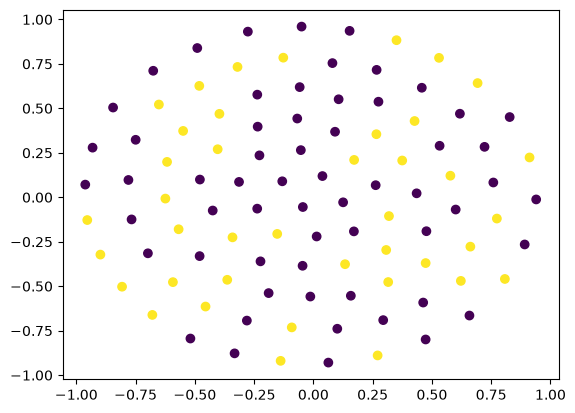

In [4]:
J = 0.1
K = 1
sol = odeint(position, z0, t, args=(J, K, N))
positions = sol[:,:2*N].reshape(len(t), N, 2)
phases = sol[:,2*N:]

plt.scatter(positions[-1, :, 0], positions[-1, :, 1], c=phases[-1,:])

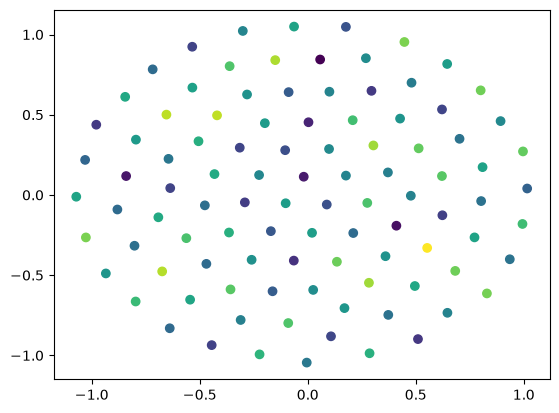

In [5]:
J = 0.1
K = -1
sol = odeint(position, z0, t, args=(J, K, N))
positions = sol[:,:2*N].reshape(len(t), N, 2)
phases = sol[:,2*N:]

plt.scatter(positions[-1, :, 0], positions[-1, :, 1], c=phases[-1,:])

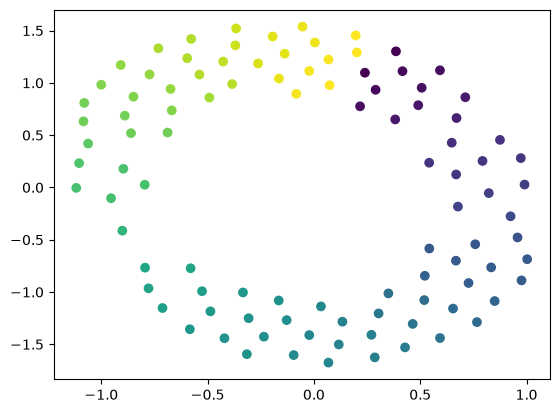

In [6]:
J = 1
K = 0
sol = odeint(position, z0, t, args=(J, K, N))
positions = sol[:,:2*N].reshape(len(t), N, 2)
phases = sol[:,2*N:]

plt.scatter(positions[-1, :, 0], positions[-1, :, 1], c=phases[-1,:])